In [2]:
import sys
sys.path.append('../..')

from src.data_loader import load_merged_data

# 단 한 줄로 결합된 데이터 불러오기 완료!
train = load_merged_data()

# 필요한 확인 작업만 수행
train.head()

데이터 결합 완료! Shape: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## 1. LightGBM 학습 + Feature Importance 추출


In [3]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# 학습에 쓸 수 없는 컬럼 제외 (ID, 타겟 등)
exclude_cols = ['TransactionID', 'isFraud']
feature_cols = [c for c in train.columns if c not in exclude_cols]

X = train[feature_cols]
y = train['isFraud']

# 범주형(문자열) 컬럼은 category 타입으로 변환 — LightGBM이 자동 처리해줌
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype('category')

# 시간순 분할 (사기탐지는 랜덤 분할보다 시간순이 더 현실적)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# LightGBM 데이터셋 생성
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_cols, reference=train_data)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 63,
    'learning_rate': 0.05,
    'scale_pos_weight': 27,  # 불균형 보정 (정상:사기 ≈ 96.5:3.5)
    'verbose': -1
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)]
)

/var/folders/3n/ld145tmn51l3ygwb17ymdk6h0000gn/T/ipykernel_25606/3608943083.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


Training until validation scores don't improve for 30 rounds
[50]	valid_0's auc: 0.925852
[100]	valid_0's auc: 0.939436
[150]	valid_0's auc: 0.946048
[200]	valid_0's auc: 0.950294
[250]	valid_0's auc: 0.953469
[300]	valid_0's auc: 0.955802
[350]	valid_0's auc: 0.958292
[400]	valid_0's auc: 0.959949
[450]	valid_0's auc: 0.961334
[500]	valid_0's auc: 0.962569
Did not meet early stopping. Best iteration is:
[500]	valid_0's auc: 0.962569


In [ ]:
# PR-AUC : 모델이 사기라고 지목한 것 중, 실제로 사기일 확률이 평균 78% 정도라는 의미
from sklearn.metrics import average_precision_score, roc_auc_score

y_pred_proba = model.predict(X_val)

roc_auc = roc_auc_score(y_val, y_pred_proba)
pr_auc = average_precision_score(y_val, y_pred_proba)
baseline = y_val.mean()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"무작위 기준선(단순 사기 비율): {baseline:.4f}")
print(f"PR-AUC가 기준선의 몇 배인가: {pr_auc/baseline:.1f}배")

ROC-AUC: 0.9626
PR-AUC: 0.7819
무작위 기준선(단순 사기 비율): 0.0350
PR-AUC가 기준선의 몇 배인가: 22.3배


/Users/jeong-seonyeong/ieee-cis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-seonyeong/ieee-cis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48128 (\N{HANGUL SYLLABLE MIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-seonyeong/ieee-cis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-seonyeong/ieee-cis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51105 (\N{HANGUL SYLLABLE JAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-seonyeong/ieee-cis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:1

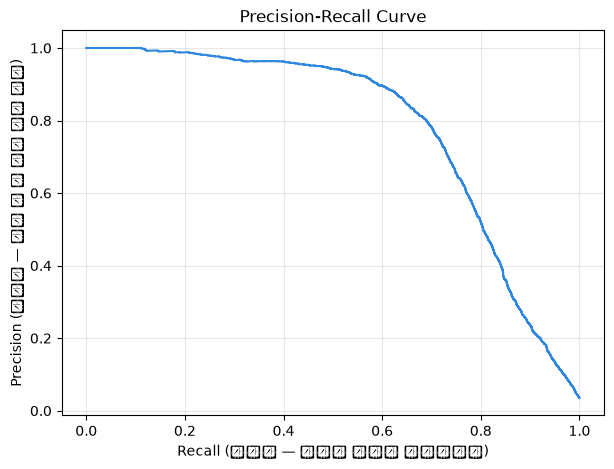

In [5]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, color='#2e86de')
plt.xlabel('Recall (재현율 — 사기를 얼마나 잡아내는가)')
plt.ylabel('Precision (정밀도 — 잡은 것 중 진짜 사기 비율)')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.show()

In [6]:
# 목표 Recall(0.65) 지점에서의 Precision과 실제 판정 기준값(Threshold)을 찾는 코드
target_idx = np.argmin(np.abs(recalls - 0.65))
print(f"Recall {recalls[target_idx]:.3f}일 때")
print(f"Precision: {precisions[target_idx]:.3f}")
print(f"Threshold: {thresholds[target_idx]:.3f}")

Recall 0.650일 때
Precision: 0.846
Threshold: 0.825


In [7]:
# LightGBM이 예측할 때 어떤 컬럼을 가장 많이/중요하게 참고했는지 순위로 뽑는 코드
importance_df = pd.DataFrame({
    'feature': model.feature_name(),
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

top20 = importance_df.head(20)
print(top20)

            feature    importance
310            V258  1.061189e+06
122             V70  5.501007e+05
28              C14  4.489749e+05
431      DeviceInfo  3.583061e+05
13    P_emaildomain  3.576587e+05
346            V294  3.023354e+05
30               D2  2.950637e+05
422           id_31  2.794173e+05
1    TransactionAmt  2.759883e+05
4             card2  2.568118e+05
3             card1  2.563750e+05
27              C13  2.257115e+05
0     TransactionDT  2.019348e+05
9             addr1  2.000853e+05
15               C1  1.912385e+05
14    R_emaildomain  1.791408e+05
22               C8  1.731871e+05
43              D15  1.557147e+05
421           id_30  1.321973e+05
8             card6  1.261174e+05


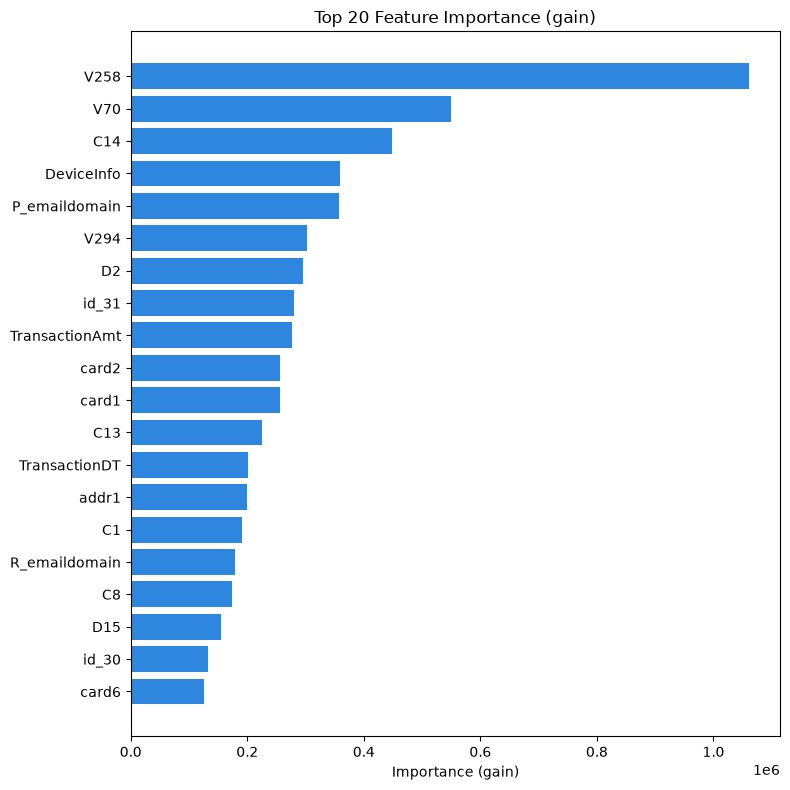

In [8]:
# 위 상위 20개를 막대그래프로 시각화하는 코드
plt.figure(figsize=(8, 8))
plt.barh(top20['feature'][::-1], top20['importance'][::-1], color='#2e86de')
plt.title('Top 20 Feature Importance (gain)')
plt.xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

In [9]:
# 구매자 이메일 도메인별 사기율을 확인하는 코드 (건수 많은 상위 도메인만)
domain_counts = train['P_emaildomain'].value_counts()
top_domains = domain_counts[domain_counts >= 500].index

result = train[train['P_emaildomain'].isin(top_domains)].groupby('P_emaildomain')['isFraud'].agg(['count', 'mean'])
print(result.sort_values('mean', ascending=False))

                 count      mean
P_emaildomain                   
mail.com           559  0.189624
outlook.com       5096  0.094584
live.com.mx        749  0.054740
hotmail.com      45250  0.052950
gmail.com       228355  0.043542
icloud.com        6267  0.031434
comcast.net       7888  0.031187
charter.net        816  0.030637
bellsouth.net     1909  0.027763
live.com          3041  0.027622
anonymous.com    36998  0.023217
yahoo.com       100934  0.022757
msn.com           4092  0.021994
aol.com          28289  0.021811
earthlink.net      514  0.021401
ymail.com         2396  0.020868
cox.net           1393  0.020818
me.com            1522  0.017740
optonline.net     1011  0.016815
yahoo.com.mx      1543  0.010369
verizon.net       2705  0.008133
att.net           4033  0.007439
sbcglobal.net     2970  0.004040
rocketmail.com     664  0.003012


In [10]:
# 이메일 도메인을 3개 그룹(위험/보통/안전)으로 나눠서 사기율 재확인하는 코드
risky_domains = ['mail.com', 'outlook.com', 'hotmail.com']
safe_domains = ['att.net', 'sbcglobal.net', 'verizon.net', 'earthlink.net', 'cox.net']

def categorize_email(domain):
    if domain in risky_domains:
        return '주의'
    elif domain in safe_domains:
        return '안전'
    else:
        return '보통'

train['email_risk_group'] = train['P_emaildomain'].apply(categorize_email)
print(train.groupby('email_risk_group')['isFraud'].agg(['count', 'mean']))

                   count      mean
email_risk_group                  
보통                528020  0.033285
안전                 11615  0.008954
주의                 50905  0.058619


/var/folders/3n/ld145tmn51l3ygwb17ymdk6h0000gn/T/ipykernel_25606/811191240.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['email_risk_group'] = train['P_emaildomain'].apply(categorize_email)


In [11]:
# 이메일 위험군과 기기 위험 여부를 동시에 조합했을 때 사기율이 어떻게 변하는지 확인하는 코드
train['is_risky_device'] = train['DeviceInfo'].isin(['hi6210sft', 'SM-A300H'])

combo = train.groupby(['email_risk_group', 'is_risky_device'])['isFraud'].agg(['count', 'mean'])
print(combo)

                                   count      mean
email_risk_group is_risky_device                  
보통               False            528019  0.033285
                 True                  1  0.000000
안전               False             11615  0.008954
주의               False             50905  0.058619


/var/folders/3n/ld145tmn51l3ygwb17ymdk6h0000gn/T/ipykernel_25606/875444174.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['is_risky_device'] = train['DeviceInfo'].isin(['hi6210sft', 'SM-A300H'])
